<a href="https://colab.research.google.com/github/Diviyah13/Machine-Learning-Portfolio-/blob/main/basic_kmeans_dbscan_wine_clustering_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy import unique, where
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/ODL ADV AL/Setting up dataset/wine+quality/winequality-red.csv',
    sep=';'
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Selecting two columns for clustering

In [ ]:
X = df[['alcohol', 'density']]

X.head()

,alcohol,density
0,9.4,0.9978
1,9.8,0.9968
2,9.8,0.9970
3,9.8,0.9980
4,9.4,0.9978


Scale the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Plot the data

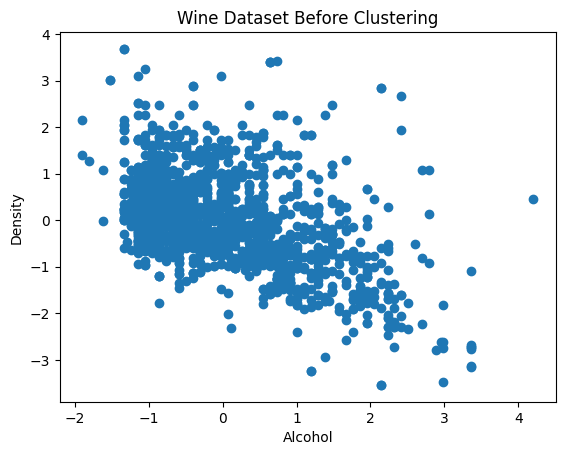

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('Wine Dataset Before Clustering')
plt.show()

using KMeans to cluster

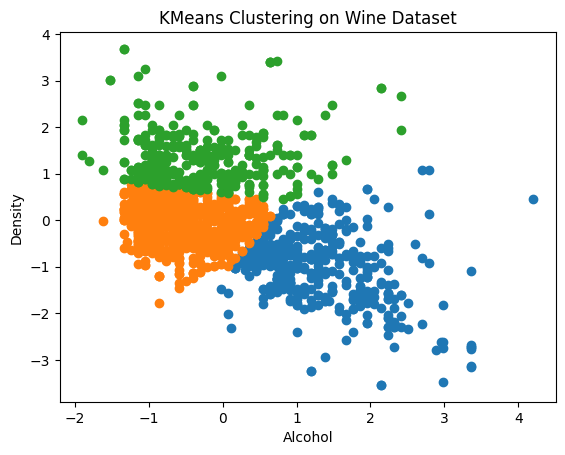

In [ ]:
model = KMeans(n_clusters=3, random_state=0) # created a KMeans clustering model. 3 groups/clusters and starts with random centroids initially.
model.fit(X_scaled) # X_scaled = standardized wine data

yhat = model.predict(X_scaled) # assigning a cluster number to every data point.

clusters = unique(yhat)

for cluster in clusters:
    row_ix = where(yhat == cluster)
    plt.scatter(X_scaled[row_ix, 0], X_scaled[row_ix, 1])

plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('KMeans Clustering on Wine Dataset')
plt.show()

using DBSCAN to cluster
Density-Based Spatial Clustering of Applications with Noise

Instead of fixed cluster counts,
DBSCAN:

groups dense areas together
identifies outliers/noise automatically


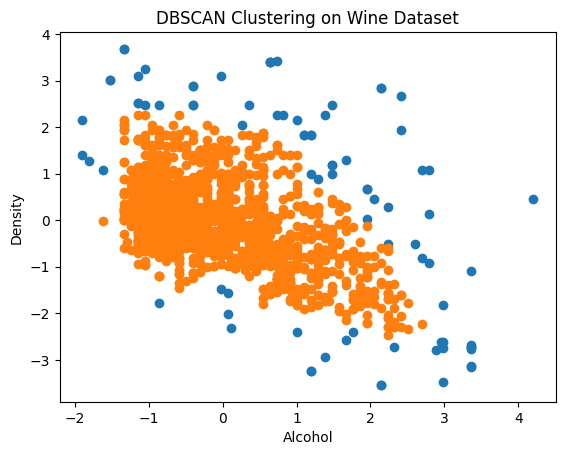

In [ ]:
model = DBSCAN(eps=0.3, min_samples=10) #eps-Defines neighborhood distance. within 0.3 distance is considered neighbours

yhat = model.fit_predict(X_scaled)

clusters = unique(yhat)

for cluster in clusters:
    row_ix = where(yhat == cluster)
    plt.scatter(X_scaled[row_ix, 0], X_scaled[row_ix, 1])

plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('DBSCAN Clustering on Wine Dataset')
plt.show()

find other 3 different clustering models. Refer to this url: https://scikit-learn.org/stable/modules/clustering.html

In this exercise, I used the Red Wine Quality dataset instead of the dummy make_moons dataset used in the video. Since clustering is unsupervised learning, the model does not use the quality column as the target. I selected alcohol and density as the input features and applied KMeans and DBSCAN clustering to group wines with similar characteristics.